In [16]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd

import torch as th
from torch import nn
import seaborn as sns

In [17]:
df = pd.read_csv('malicious_phish.csv')
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [18]:
df.describe()

,url,type
count,651191,651191
unique,641119,4
top,http://style.org.hc360.com/css/detail/mysite/s...,benign
freq,180,428103


In [19]:
df['type'].value_counts()

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Text(0, 0.5, 'Count')

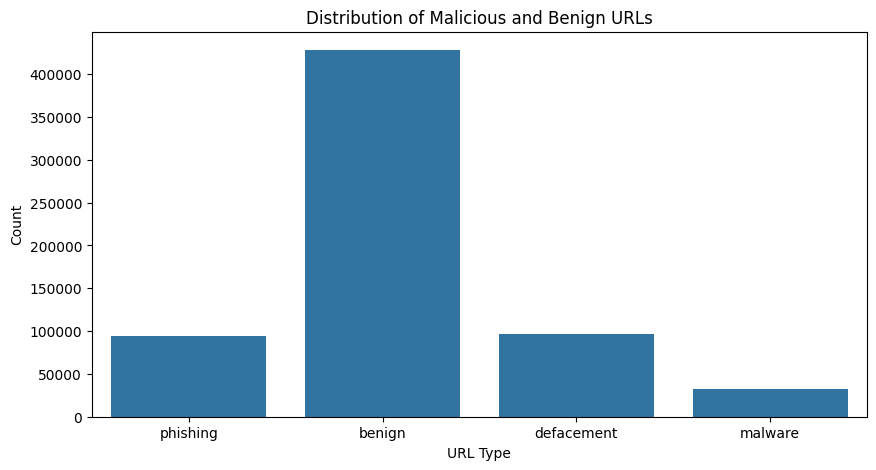

In [20]:
plt.figure(figsize=(10,5))
plt.title('Distribution of Malicious and Benign URLs')
sns.countplot(x='type',data = df)
plt.xlabel('URL Type')
plt.ylabel('Count')


**Feature Engineering**
 
We will now extract features from URLs, and use them to train machine learning model

has_ip_address: It's common for malicious links to have an ip address instead of domain name, this function if url has a IP address in domain.

In [25]:
import re  

def has_ip_address(url):
    # Regular expression to match IPv4 addresses
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url) # IPv6

    if match:
        return 1
    else:
        return 0
    
df['has_ip'] = df['url'].apply(has_ip_address)
df[df['has_ip'] == 1].head()
    

,url,type,has_ip
10408,http://219.232.244.89/intl/update/error_login.htm,phishing,1
12441,boards.ancestry.com/topics.ethnic.natam.nation...,benign,1
12853,http://www.controlyourbreath.com/new/css_/img/...,phishing,1
13161,http://www.reqntpvw.com/Public/softs/everythin...,malware,1
14915,http://66.208.115.70/images/index.asp,phishing,1


In [26]:
df['has_ip'].value_counts()

has_ip
0    643898
1      7293
Name: count, dtype: int64

check_google_index: Will check if the URL is in google search console

In [ ]:
from googlesearch import search

def check_google_index(url):
    site = search(url, 5)
    if site:
        return 1
    else:
        return 0

df['in_google_index'] = df['url'].apply(check_google_index)

    

,url,type,has_ip,in_google_index


count_dot: checks, if the url has multiple subdomains, by checking the ammount of dots, url's with three or more sub domains are more likely to be malicious 

In [31]:
def count_dot(url):
    return url.count('.')

df['dot_count'] = df['url'].apply(count_dot)

In [32]:
df['dot_count'].value_counts()

dot_count
2     236038
1     219105
3     129667
4      40227
5       9436
6       5729
7       3570
8       1566
9       1150
10      1114
11       973
12       757
13       505
14       379
15       259
16       144
20       129
17       118
19        88
18        70
0         61
22        24
24        22
21        18
23        10
25         9
36         5
27         4
26         4
35         3
42         3
31         1
37         1
34         1
28         1
Name: count, dtype: int64